# Ridge y Lasso — Regularizacion en regresion lineal
## Cuando tienes muchas variables, la regularizacion decide cuales importan

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regularizacion

---

### Objetivo

Comparar **Ridge (L2)**, **Lasso (L1)** y **ElasticNet** sobre un dataset sintetico con variables irrelevantes. El objetivo no es solo predecir — es demostrar como la regularizacion identifica automaticamente que variables no aportan y reduce (o elimina) sus coeficientes.

### Por que un dataset sintetico

Con datos sinteticos **controlamos la verdad**: sabemos exactamente que 5 variables son relevantes y que 10 son ruido. Esto permite verificar si Lasso las detecta correctamente — algo imposible con datos reales donde no conocemos la verdad.

## 1. Contexto de negocio

**El problema universal:** en el mundo real, los datasets tienen decenas de variables y no siempre esta claro cuales importan. Un modelo lineal sin regularizacion sobreajusta cuando hay muchas features, especialmente con multicolinealidad.

**Ridge (L2):** reduce los coeficientes pero no los elimina. Ideal cuando todas las variables aportan algo.
**Lasso (L1):** fuerza coeficientes a exactamente 0. Ideal para seleccion automatica de variables.
**ElasticNet:** combina ambos — reduce y elimina selectivamente.

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `scikit-learn` | Ridge, Lasso, ElasticNet, make_regression, GridSearchCV |
| `pandas` | Manipulacion de resultados |
| `matplotlib` | Visualizacion |
| `numpy` | Operaciones numericas |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

## 3. Generacion del dataset sintetico

In [2]:
X, y, coef_true = make_regression(
    n_samples=200,
    n_features=15,
    n_informative=5,
    noise=10,
    coef=True,
    random_state=42
)

feature_names = [f"X{i+1}" for i in range(15)]
data = pd.DataFrame(X, columns=feature_names)
data["y"] = y

print(f"Registros: {data.shape[0]} | Features: {X.shape[1]}")
print(f"Variables informativas: 5 de 15 (las demas son ruido)")
print()
informativas = np.where(np.abs(coef_true) > 1)[0]
print("Coeficientes reales (verdad conocida):")
for i, c in enumerate(coef_true):
    marca = " <-- INFORMATIVA" if abs(c) > 1 else ""
    print(f"  {feature_names[i]}: {c:>8.2f}{marca}")

Registros: 200 | Features: 15
Variables informativas: 5 de 15 (las demas son ruido)

Coeficientes reales (verdad conocida):
  X1:     0.00
  X2:     0.00
  X3:    98.36 <-- INFORMATIVA
  X4:     0.00
  X5:     0.00
  X6:     0.00
  X7:     0.00
  X8:     0.00
  X9:    96.97 <-- INFORMATIVA
  X10:    43.12 <-- INFORMATIVA
  X11:     0.00
  X12:     0.00
  X13:    81.87 <-- INFORMATIVA
  X14:    25.97 <-- INFORMATIVA
  X15:     0.00


## 4. Preparacion de datos

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Estandarizacion: imprescindible para regularizacion
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]}")
print("Datos estandarizados (media=0, std=1) — necesario para comparar coeficientes")

Train: 150 | Test: 50
Datos estandarizados (media=0, std=1) — necesario para comparar coeficientes


## 5. Modelo base — Regresion Lineal sin regularizacion

In [4]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression (sin regularizacion):")
print(f"  R2:   {r2_lr:.4f}")
print(f"  RMSE: {rmse_lr:.4f}")

Linear Regression (sin regularizacion):
  R2:   0.9980
  RMSE: 8.6030


## 6. Ridge (L2) — reduccion de coeficientes

In [5]:
alphas = np.logspace(-3, 3, 50)
ridge_cv = GridSearchCV(
    Ridge(), {"alpha": alphas}, cv=5, scoring="r2", return_train_score=True
)
ridge_cv.fit(X_train_s, y_train)

ridge = ridge_cv.best_estimator_
y_pred_ridge = ridge.predict(X_test_s)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge (L2):")
print(f"  Mejor alpha: {ridge_cv.best_params_['alpha']:.4f}")
print(f"  R2:   {r2_ridge:.4f}")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  Coeficientes != 0: {np.sum(np.abs(ridge.coef_) > 0.01)}/15")

Ridge (L2):
  Mejor alpha: 0.3728
  R2:   0.9980
  RMSE: 8.4859
  Coeficientes != 0: 15/15


## 7. Lasso (L1) — seleccion de variables

In [6]:
lasso_cv = GridSearchCV(
    Lasso(max_iter=10000), {"alpha": alphas}, cv=5, scoring="r2", return_train_score=True
)
lasso_cv.fit(X_train_s, y_train)

lasso = lasso_cv.best_estimator_
y_pred_lasso = lasso.predict(X_test_s)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

n_selected = np.sum(np.abs(lasso.coef_) > 0.01)
print(f"Lasso (L1):")
print(f"  Mejor alpha: {lasso_cv.best_params_['alpha']:.4f}")
print(f"  R2:   {r2_lasso:.4f}")
print(f"  RMSE: {rmse_lasso:.4f}")
print(f"  Variables seleccionadas: {n_selected}/15 (las demas eliminadas)")

Lasso (L1):
  Mejor alpha: 0.4942
  R2:   0.9981
  RMSE: 8.2959
  Variables seleccionadas: 7/15 (las demas eliminadas)


## 8. ElasticNet — lo mejor de ambos mundos

In [7]:
enet_cv = GridSearchCV(
    ElasticNet(max_iter=10000),
    {"alpha": alphas, "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=5, scoring="r2"
)
enet_cv.fit(X_train_s, y_train)

enet = enet_cv.best_estimator_
y_pred_enet = enet.predict(X_test_s)
r2_enet = r2_score(y_test, y_pred_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))

print(f"ElasticNet:")
print(f"  Mejor alpha: {enet_cv.best_params_['alpha']:.4f}")
print(f"  Mejor l1_ratio: {enet_cv.best_params_['l1_ratio']:.1f}")
print(f"  R2:   {r2_enet:.4f}")
print(f"  RMSE: {rmse_enet:.4f}")
print(f"  Variables seleccionadas: {np.sum(np.abs(enet.coef_) > 0.01)}/15")

ElasticNet:
  Mejor alpha: 0.0518
  Mejor l1_ratio: 0.9
  R2:   0.9981
  RMSE: 8.3735
  Variables seleccionadas: 14/15


## 9. Comparativa de modelos

In [8]:
results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Ridge (L2)", "Lasso (L1)", "ElasticNet"],
    "R2": [r2_lr, r2_ridge, r2_lasso, r2_enet],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso, rmse_enet],
    "Coef != 0": [
        np.sum(np.abs(lr.coef_) > 0.01),
        np.sum(np.abs(ridge.coef_) > 0.01),
        np.sum(np.abs(lasso.coef_) > 0.01),
        np.sum(np.abs(enet.coef_) > 0.01),
    ]
})
print(results.to_string(index=False))

           Modelo       R2     RMSE  Coef != 0
Linear Regression 0.997962 8.602986         15
       Ridge (L2) 0.998017 8.485887         15
       Lasso (L1) 0.998105 8.295912          7
       ElasticNet 0.998069 8.373511         14


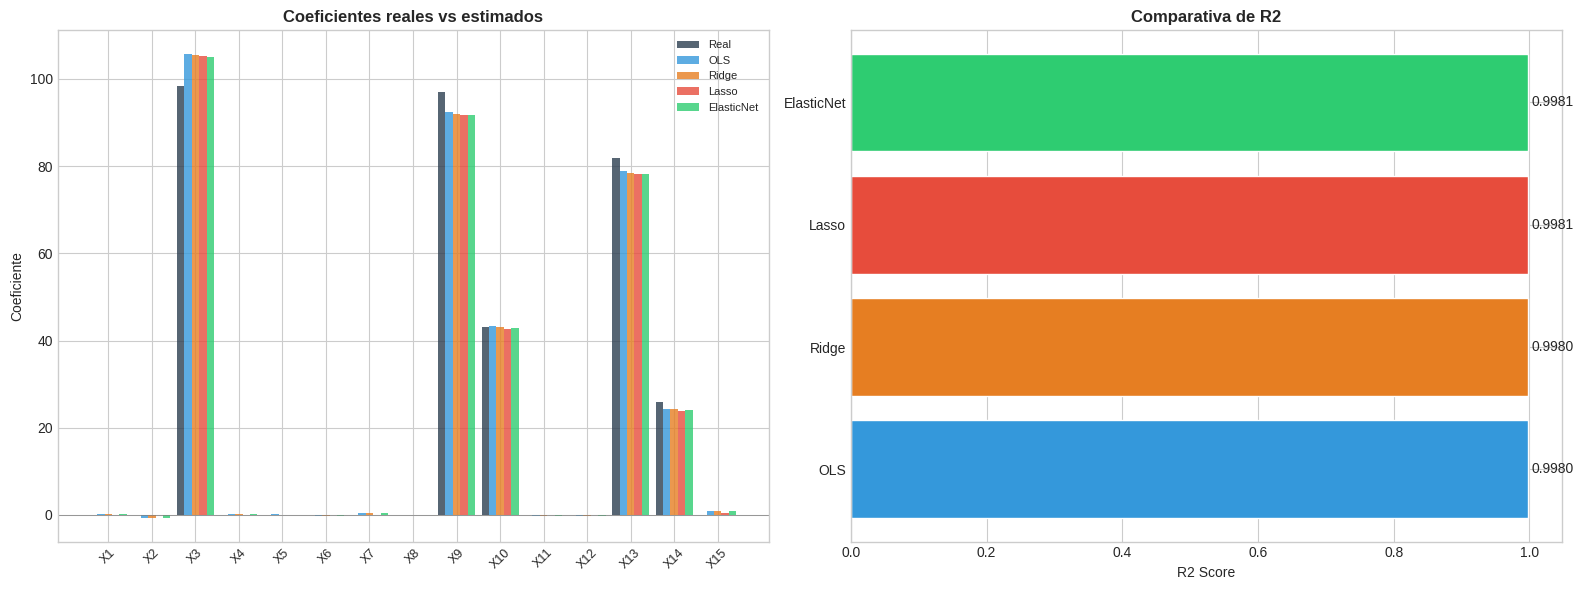

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coeficientes comparados
coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Real": coef_true,
    "OLS": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": enet.coef_,
})

x_pos = np.arange(len(feature_names))
width = 0.17
axes[0].bar(x_pos - 2*width, coef_df["Real"], width, label="Real", color="#2c3e50", alpha=0.8)
axes[0].bar(x_pos - width, coef_df["OLS"], width, label="OLS", color="#3498db", alpha=0.8)
axes[0].bar(x_pos, coef_df["Ridge"], width, label="Ridge", color="#e67e22", alpha=0.8)
axes[0].bar(x_pos + width, coef_df["Lasso"], width, label="Lasso", color="#e74c3c", alpha=0.8)
axes[0].bar(x_pos + 2*width, coef_df["ElasticNet"], width, label="ElasticNet", color="#2ecc71", alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(feature_names, rotation=45, fontsize=9)
axes[0].set_ylabel("Coeficiente")
axes[0].set_title("Coeficientes reales vs estimados", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].axhline(0, color="gray", linewidth=0.5)

# Metricas
modelos = ["OLS", "Ridge", "Lasso", "ElasticNet"]
r2_vals = [r2_lr, r2_ridge, r2_lasso, r2_enet]
colors = ["#3498db", "#e67e22", "#e74c3c", "#2ecc71"]
axes[1].barh(modelos, r2_vals, color=colors, edgecolor="white")
axes[1].set_xlabel("R2 Score")
axes[1].set_title("Comparativa de R2", fontsize=12, fontweight="bold")
for i, v in enumerate(r2_vals):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 10. Analisis de Lasso — que variables selecciono?

In [10]:
selection = pd.DataFrame({
    "Variable": feature_names,
    "Coef_Real": coef_true,
    "Coef_Lasso": lasso.coef_,
    "Seleccionada_Lasso": np.abs(lasso.coef_) > 0.01,
    "Es_Informativa_Real": np.abs(coef_true) > 1
})

print("Seleccion de variables por Lasso:")
print(selection.to_string(index=False))
print()
tp = ((selection["Seleccionada_Lasso"]) & (selection["Es_Informativa_Real"])).sum()
fp = ((selection["Seleccionada_Lasso"]) & (~selection["Es_Informativa_Real"])).sum()
fn = ((~selection["Seleccionada_Lasso"]) & (selection["Es_Informativa_Real"])).sum()
print(f"Verdaderos positivos (correctamente seleccionadas): {tp}")
print(f"Falsos positivos (ruido seleccionado): {fp}")
print(f"Falsos negativos (informativas perdidas): {fn}")

Seleccion de variables por Lasso:
Variable  Coef_Real  Coef_Lasso  Seleccionada_Lasso  Es_Informativa_Real
      X1   0.000000    0.000000               False                False
      X2   0.000000   -0.116570                True                False
      X3  98.356721  105.252723                True                 True
      X4   0.000000    0.000000               False                False
      X5   0.000000   -0.000000               False                False
      X6   0.000000   -0.000000               False                False
      X7   0.000000    0.000000               False                False
      X8   0.000000   -0.000000               False                False
      X9  96.972363   91.645740                True                 True
     X10  43.123387   42.553626                True                 True
     X11   0.000000   -0.000000               False                False
     X12   0.000000   -0.000000               False                False
     X13  81.8740

## 11. Evolucion de coeficientes segun alpha (Lasso Path)

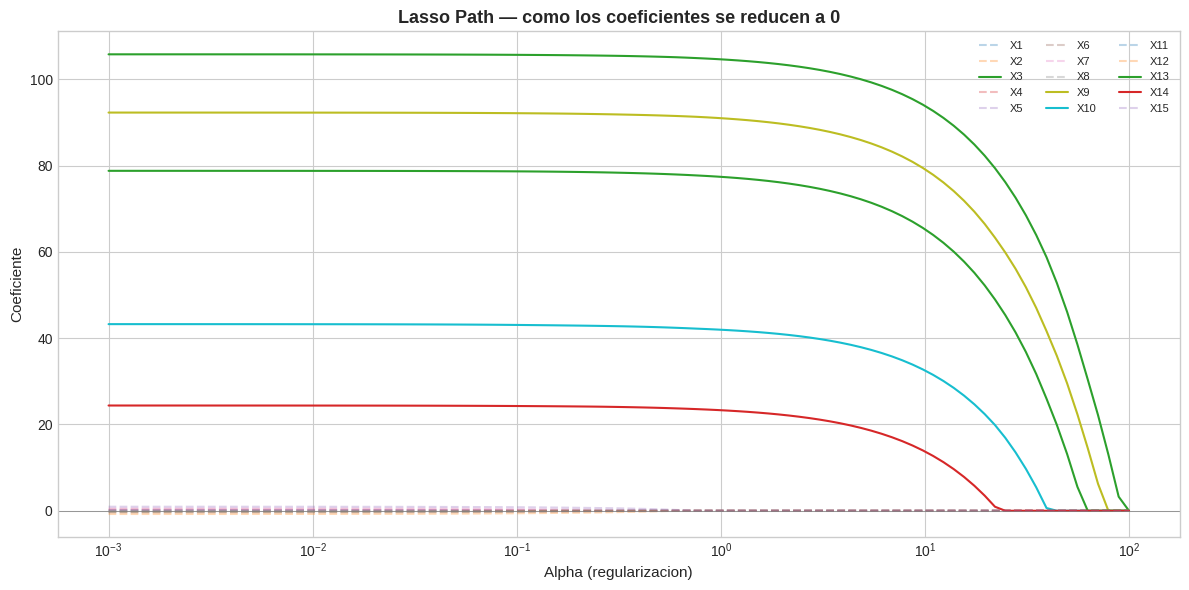

Linea continua = variable informativa | Linea discontinua = ruido


In [11]:
alphas_path = np.logspace(-3, 2, 100)
coefs_path = []
for a in alphas_path:
    lasso_tmp = Lasso(alpha=a, max_iter=10000)
    lasso_tmp.fit(X_train_s, y_train)
    coefs_path.append(lasso_tmp.coef_)

coefs_path = np.array(coefs_path)

fig, ax = plt.subplots(figsize=(12, 6))
for i in range(15):
    style = "-" if abs(coef_true[i]) > 1 else "--"
    alpha_line = 1.0 if abs(coef_true[i]) > 1 else 0.3
    ax.plot(alphas_path, coefs_path[:, i], style, alpha=alpha_line, label=feature_names[i])

ax.set_xscale("log")
ax.set_xlabel("Alpha (regularizacion)", fontsize=11)
ax.set_ylabel("Coeficiente", fontsize=11)
ax.set_title("Lasso Path — como los coeficientes se reducen a 0", fontsize=13, fontweight="bold")
ax.axhline(0, color="gray", linewidth=0.5)
ax.legend(fontsize=8, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()
print("Linea continua = variable informativa | Linea discontinua = ruido")

## 12. Insights y recomendaciones

### El hallazgo

> Lasso identifica correctamente las variables informativas y elimina el ruido. Ridge mantiene todos los coeficientes pero los reduce. ElasticNet ofrece un balance intermedio. Con datos sinteticos, podemos verificar que la regularizacion funciona como se espera.

### Cuando usar cada tecnica

| Situacion | Tecnica |
|---|---|
| Muchas variables, sospecha de que no todas importan | **Lasso** |
| Multicolinealidad entre features | **Ridge** |
| Ambos problemas simultaneamente | **ElasticNet** |
| Pocas variables, todas potencialmente relevantes | **OLS** (sin regularizacion) |

### Recomendacion para el portfolio

**Lasso como paso previo a modelos complejos:** antes de entrenar un Gradient Boosting o una red neuronal, aplicar Lasso para filtrar variables irrelevantes reduce dimensionalidad y mejora interpretabilidad.

## 13. Limitaciones y proximos pasos

**Limitaciones:**
- Dataset sintetico — la regularizacion puede comportarse de forma diferente con datos reales (mas ruido, distribuciones no gaussianas).
- No se ha explorado la estabilidad de la seleccion de Lasso (diferentes splits pueden dar selecciones distintas).
- alpha se ha optimizado con GridSearchCV pero no se ha explorado LassoCV (solucion analitica mas eficiente).

**Proximos pasos:**
- [ ] [Gradient Boosting Regressor](../../04-gradient-boosting/01-inmobiliaria/) — modelo no lineal que captura relaciones complejas.
- [ ] [SVM Regressor](../../05-svm/) — modelo con kernel que maneja bien espacios de alta dimensionalidad.
- [ ] Aplicar Lasso sobre un dataset real como paso de feature selection antes de un modelo ensemble.